<a href="https://colab.research.google.com/github/Osujan/MLTSA25_SShrestha/blob/main/HW7/autoencoder_time_series_instructions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autoencoder for time series
an autoencoder is a deep neural network that reproduces input data

it does so by progressively shrinking the size of the layers from the input size to a bottle neck and then expanding them back progressively to the initial size

note: the input and target are the same!

put your imports in the top cell

In [73]:
#Deep leaarning imports
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping, ModelCheckpoint
import glob
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as pl


get the data by cloaning the repo https://github.com/nlandolfi/acc2022treelinearcascades_stocks.git

In [34]:
!git clone https://github.com/nlandolfi/acc2022treelinearcascades_stocks

fatal: destination path 'acc2022treelinearcascades_stocks' already exists and is not an empty directory.


In [35]:
ls

acc2022treelinearcascades_stocks/  sample_data/


In [36]:
ls acc2022treelinearcascades_stocks/data

aapl.csv  cat.csv   dis.csv  ibm.csv   ko.csv   msft.csv  unh.csv  wmt.csv
amgn.csv  crm.csv   gs.csv   intc.csv  mcd.csv  nke.csv   v.csv
axp.csv   csco.csv  hd.csv   jnj.csv   mmm.csv  pg.csv    vz.csv
ba.csv    cvx.csv   hon.csv  jpm.csv   mrk.csv  trv.csv   wba.csv


check that all files have the same length. The system command `wc -l returns` the  number of lines (stands for "word count -lines")

In [37]:
!wc -l acc2022treelinearcascades_stocks/data/*

   2516 acc2022treelinearcascades_stocks/data/aapl.csv
   2516 acc2022treelinearcascades_stocks/data/amgn.csv
   2516 acc2022treelinearcascades_stocks/data/axp.csv
   2516 acc2022treelinearcascades_stocks/data/ba.csv
   2516 acc2022treelinearcascades_stocks/data/cat.csv
   2516 acc2022treelinearcascades_stocks/data/crm.csv
   2516 acc2022treelinearcascades_stocks/data/csco.csv
   2516 acc2022treelinearcascades_stocks/data/cvx.csv
   2516 acc2022treelinearcascades_stocks/data/dis.csv
   2516 acc2022treelinearcascades_stocks/data/gs.csv
   2516 acc2022treelinearcascades_stocks/data/hd.csv
   2516 acc2022treelinearcascades_stocks/data/hon.csv
   2516 acc2022treelinearcascades_stocks/data/ibm.csv
   2516 acc2022treelinearcascades_stocks/data/intc.csv
   2516 acc2022treelinearcascades_stocks/data/jnj.csv
   2516 acc2022treelinearcascades_stocks/data/jpm.csv
   2516 acc2022treelinearcascades_stocks/data/ko.csv
   2516 acc2022treelinearcascades_stocks/data/mcd.csv
   2516 acc2022treelinearcas

In [38]:
!rm acc2022treelinearcascades_stocks/data/dow.csv

rm: cannot remove 'acc2022treelinearcascades_stocks/data/dow.csv': No such file or directory


In [39]:
#create a list of all files you want to load
files = glob.glob("acc2022treelinearcascades_stocks/data/*")

In [41]:
n_files = len(files)
with open(files[0], 'r') as f:
    n_lines = sum(1 for line in f) -1  # subtract 1 to exclude header row
data = np.zeros((n_files, n_lines))


In [43]:
data.shape

(29, 2516)

 read in all the data into the array

In [42]:
# prompt: read in all the data into the array
# for i,f in tqdm(enumerate(files)):
#   ....

from tqdm import tqdm

for i,f in tqdm(enumerate(files)):
    df = np.genfromtxt(f, delimiter=',', skip_header=1)
    data[i, :] = df[:min_length, 5] # Assuming the "Volume" column is the 6th (index 5)


29it [00:00, 52.97it/s]


plot the time series

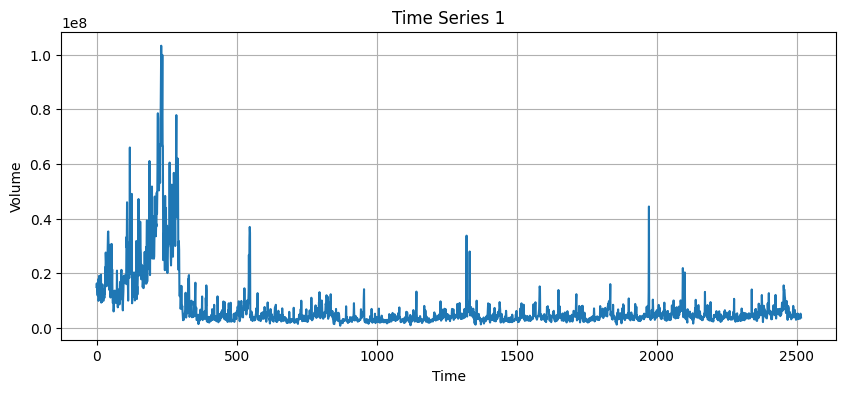

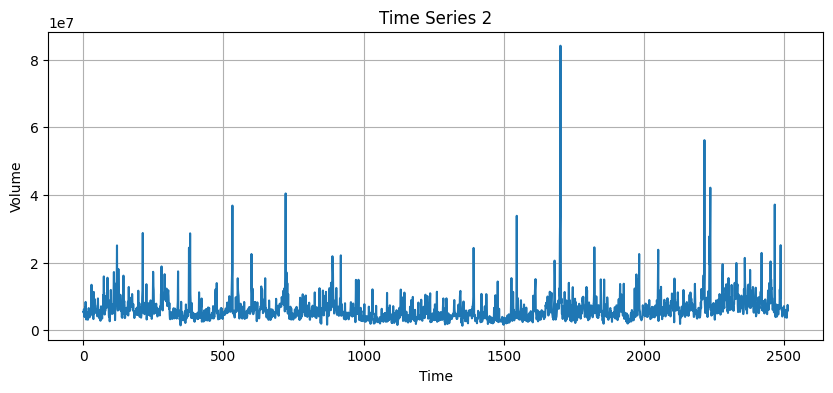

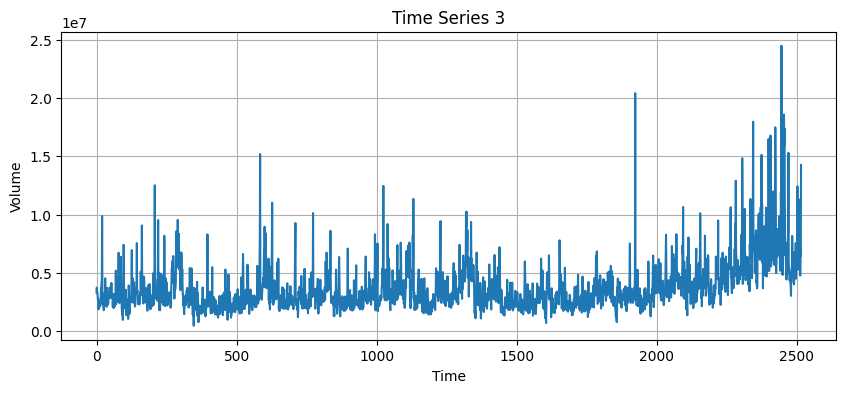

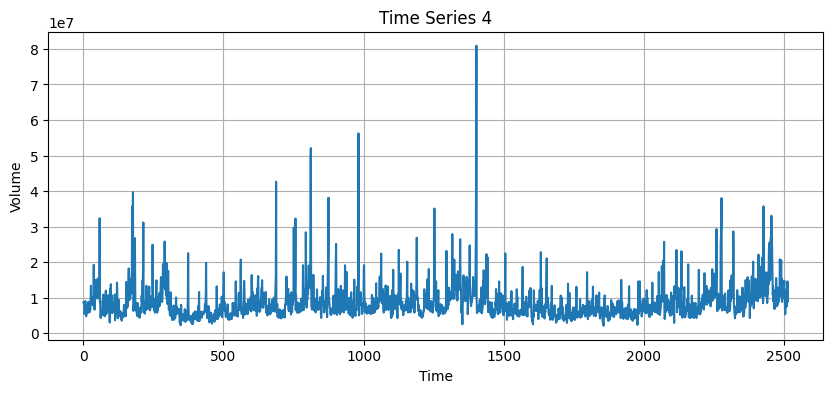

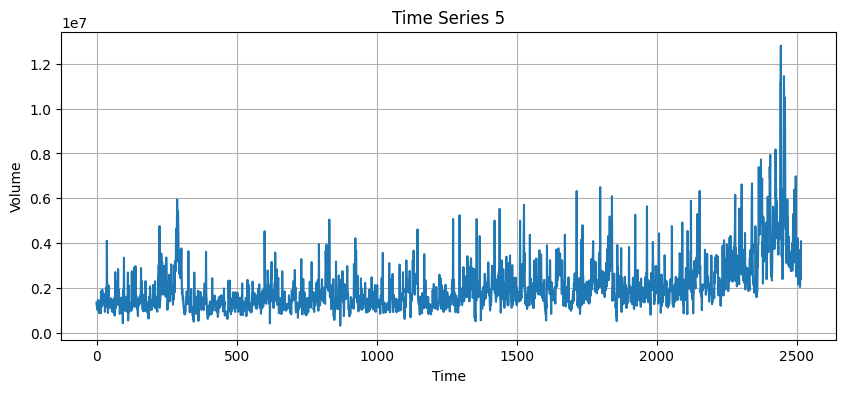

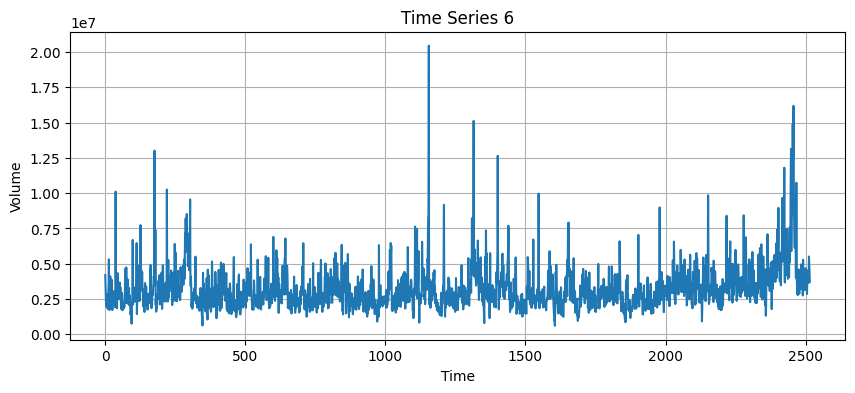

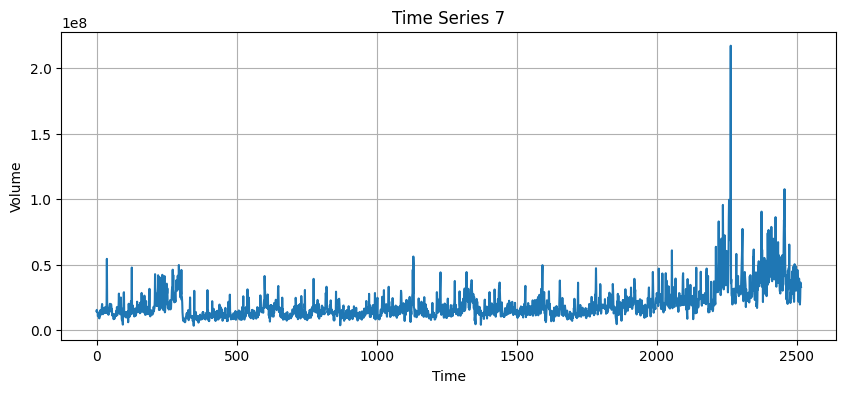

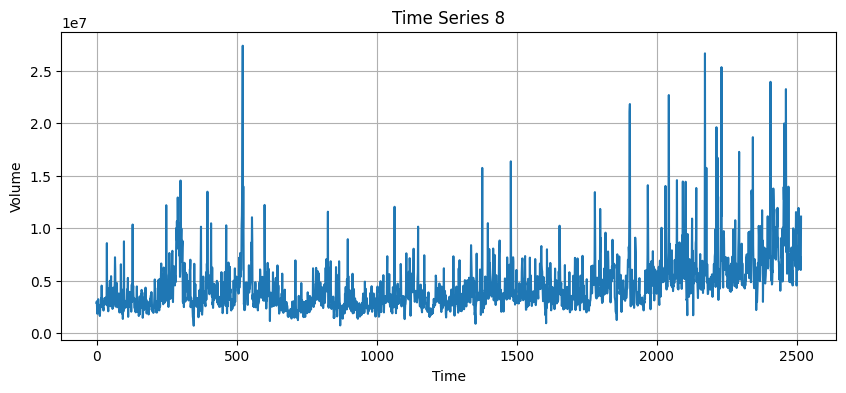

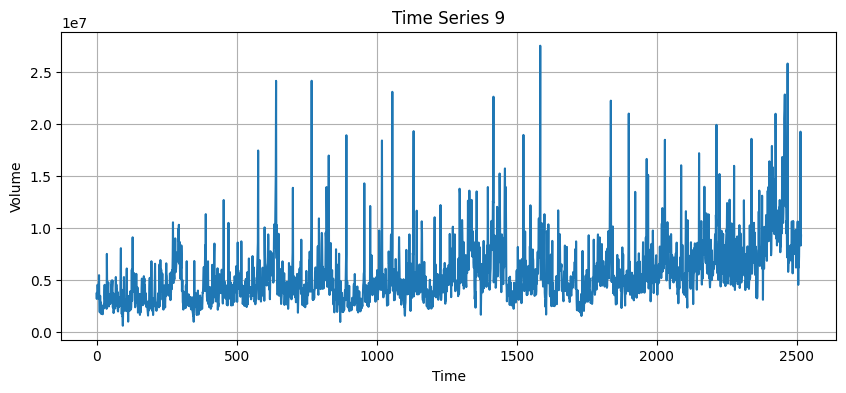

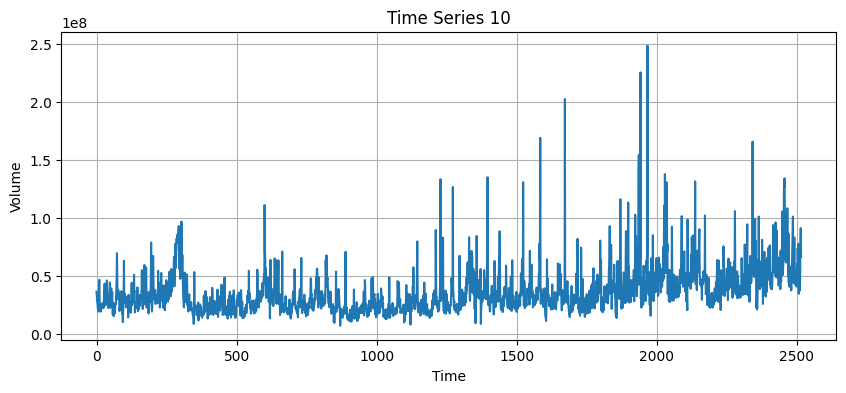

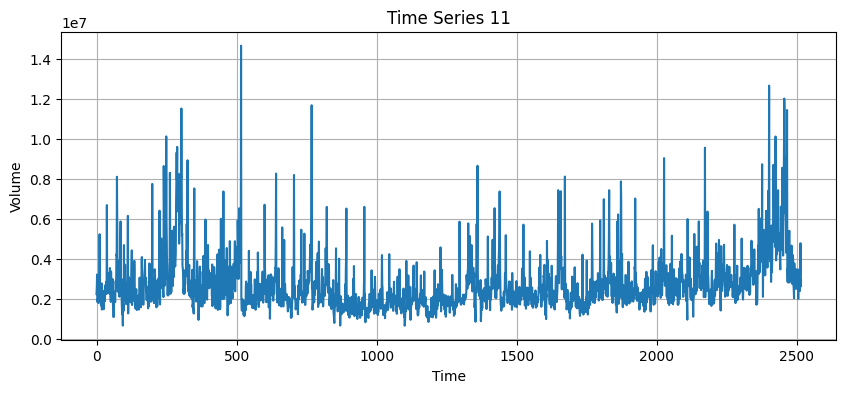

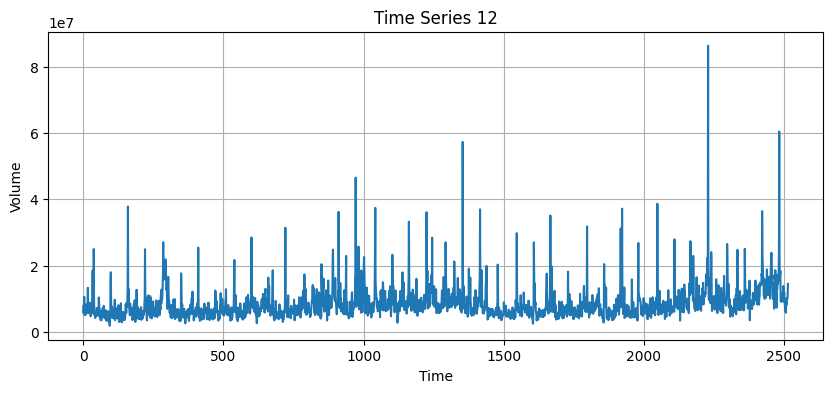

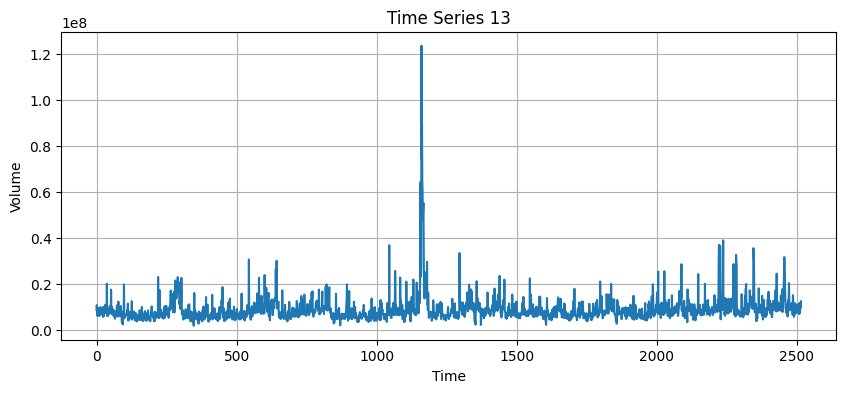

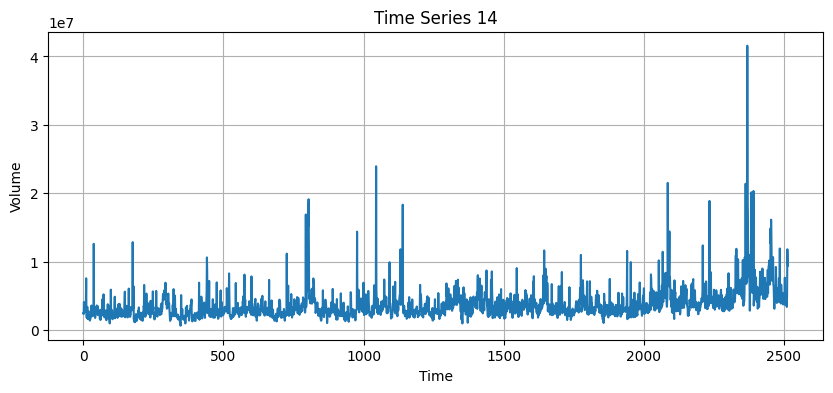

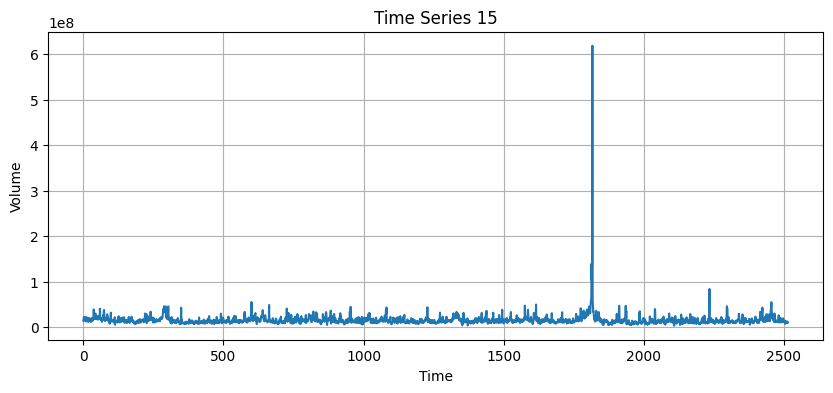

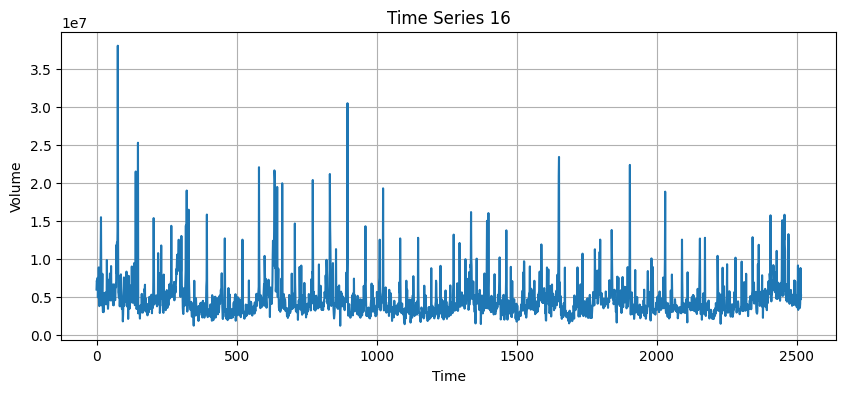

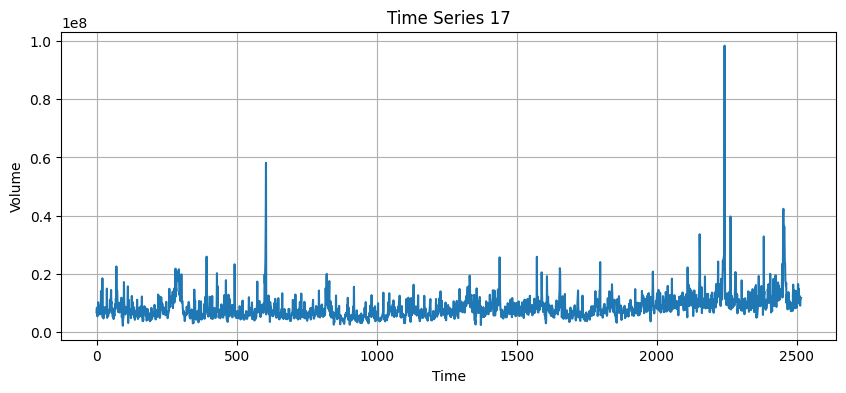

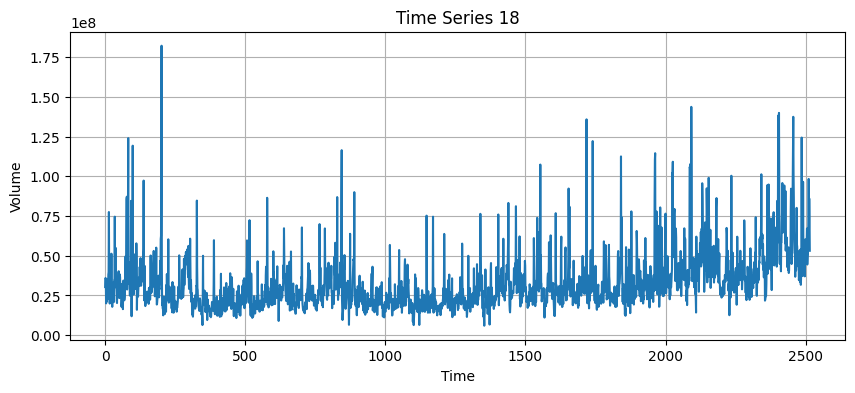

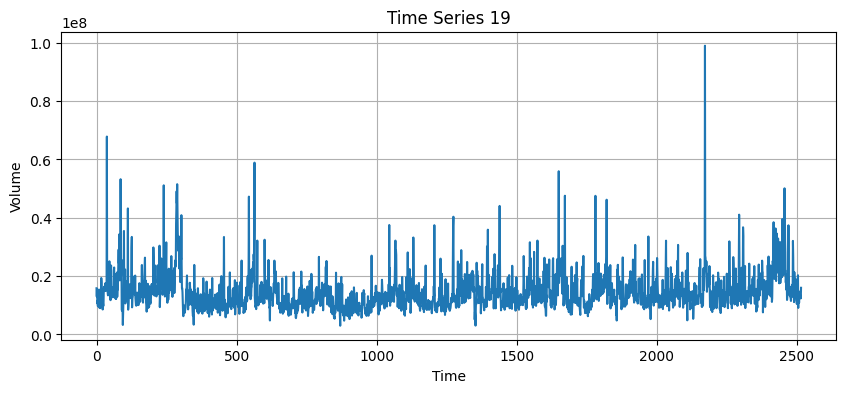

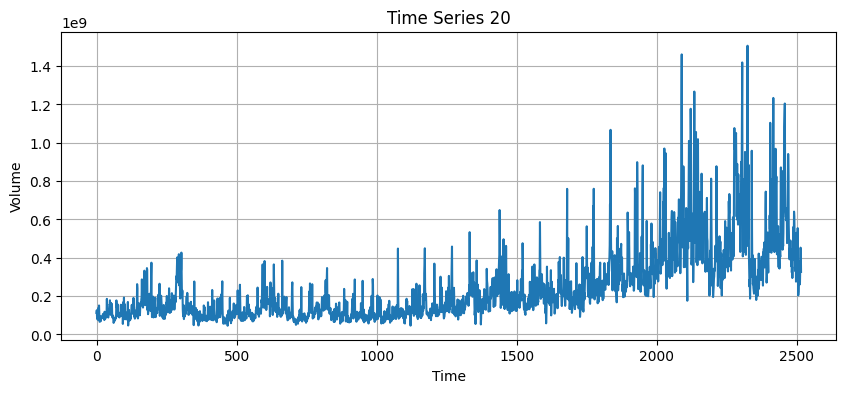

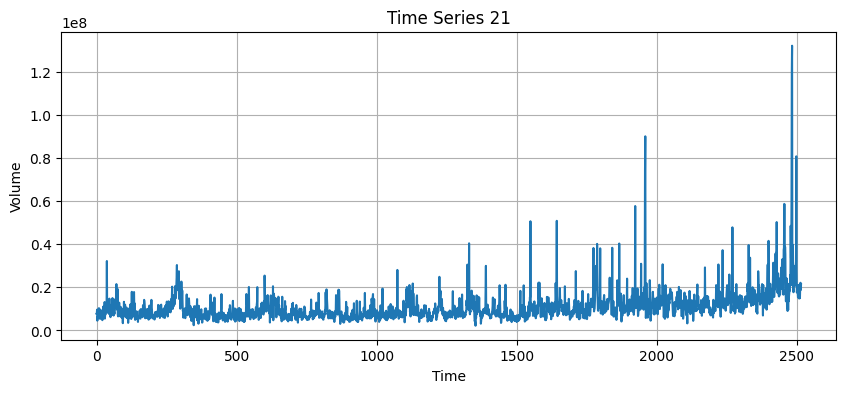

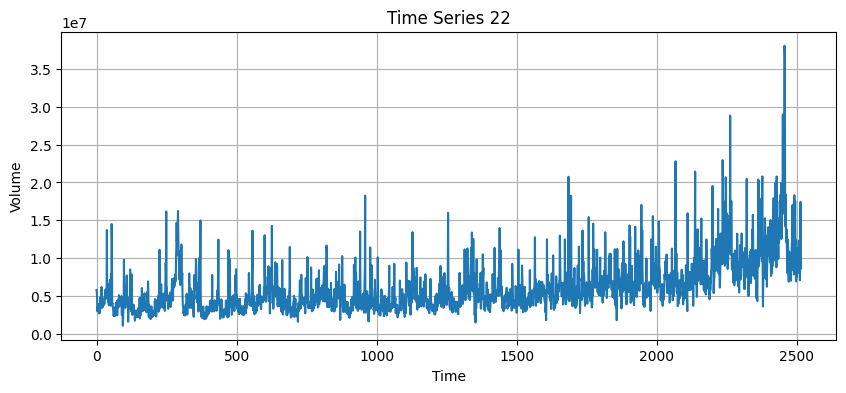

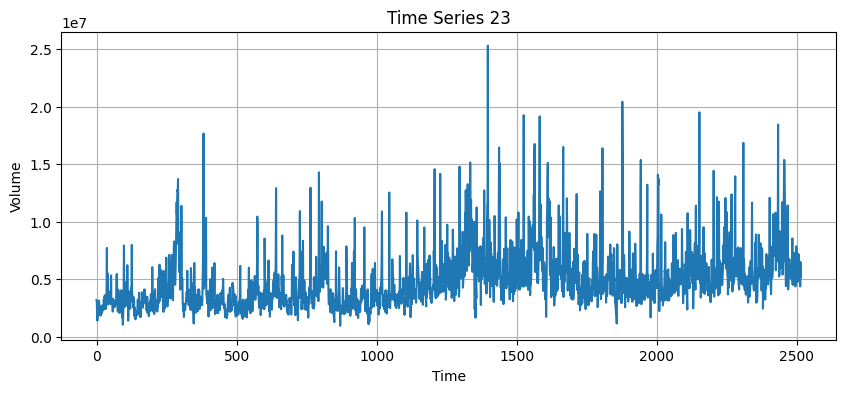

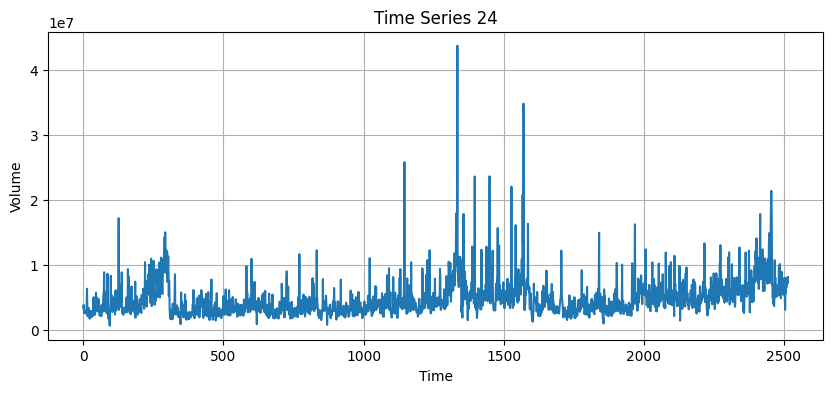

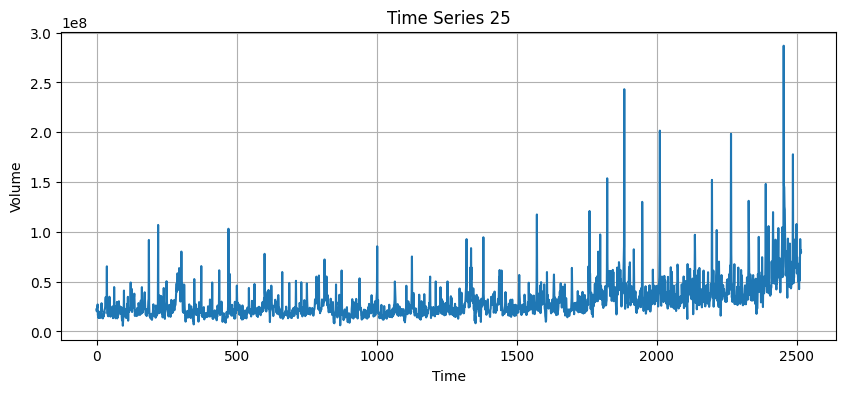

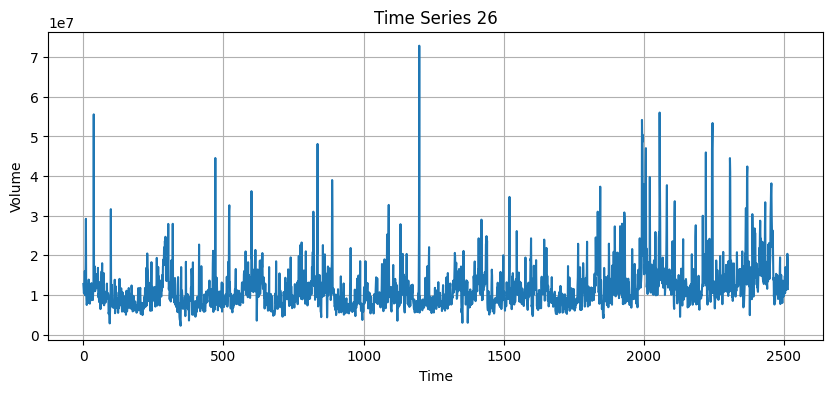

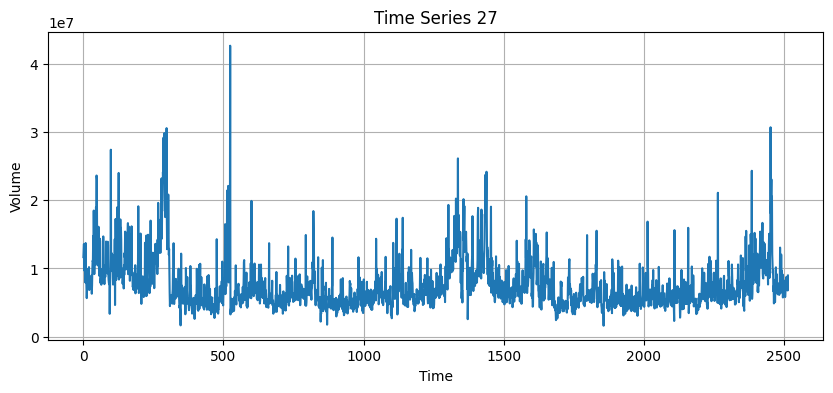

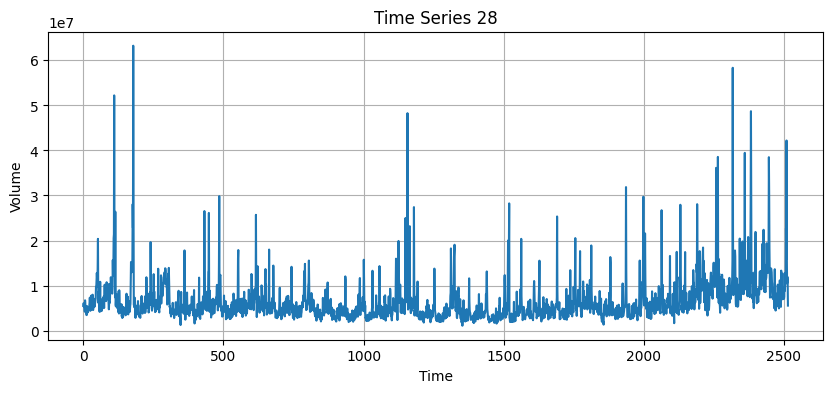

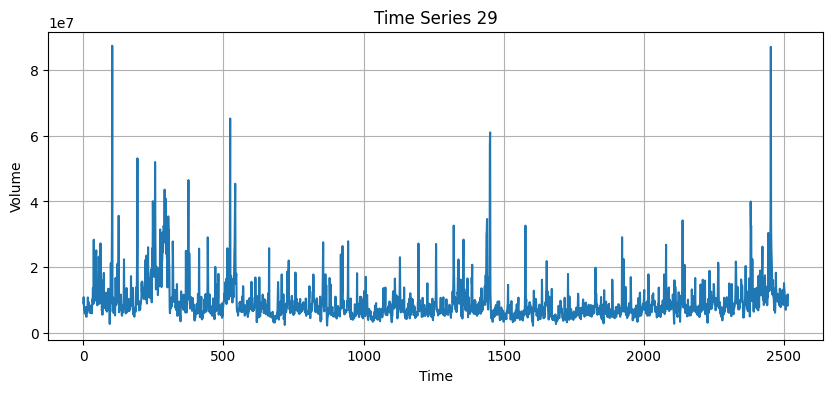

In [44]:
# prompt: plot the time series




for i in range(data.shape[0]):
    pl.figure(figsize=(10, 4))
    pl.plot(data[i, :])
    pl.title(f"Time Series {i+1}")
    pl.xlabel("Time")
    pl.ylabel("Volume")
    pl.grid(True)
    pl.show()


Figure 1: This figure shows the plots of each time series before normalization. In each of these plots, the horizontal axis represents the time and the vertical axis represents the volume. This allows us to observe the general shape of most of the time series. We see that the time series tend to stay near a certain mean value, with large amounts of noise. In some of the time series the average stays constant throughout, while in others the average changes over time.

scale the time series appropriately
hint: use Standard Scaler to save the mean and standard deviation of each time series, that way you can apply them later to your predicted results

In [50]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data.T).T
print(scaler.mean_)

[7.31825091e+06 6.22716013e+06 3.69958000e+06 8.56753041e+06
 2.00906164e+06 3.20954830e+06 1.95325344e+07 4.47784854e+06
 5.49183710e+06 3.61821291e+07 2.70803716e+06 8.38845291e+06
 9.05137382e+06 3.68032742e+06 1.57255425e+07 4.64859694e+06
 8.38605635e+06 3.23061745e+07 1.44888552e+07 2.41918808e+08
 1.07715065e+07 6.13210239e+06 4.83503569e+06 4.82569939e+06
 3.04478866e+07 1.16112013e+07 7.59459024e+06 6.39931196e+06
 9.22106420e+06]


In [51]:
scaled_data.mean(axis=1)

array([ 0.00000000e+00,  7.90747083e-17, -6.77783214e-17,  8.47229017e-17,
        9.03710952e-17, -1.12963869e-17, -9.03710952e-17,  1.58149417e-16,
       -6.77783214e-17, -1.12963869e-16,  1.58149417e-16, -6.77783214e-17,
        5.36578378e-17, -1.12963869e-16,  7.20144665e-17,  2.54168705e-17,
        9.03710952e-17,  4.51855476e-17,  3.38891607e-17,  1.35556643e-16,
       -9.03710952e-17, -9.03710952e-17, -1.35556643e-16, -4.51855476e-17,
       -4.51855476e-17, -9.03710952e-17,  2.25927738e-17,  0.00000000e+00,
       -6.21301279e-17])

In [52]:
scaled_data.std(axis=1)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

split traiing and testimg data

In [55]:

training_set, test_set = train_test_split(scaled_data, test_size=0.2)
X_train, y_train = training_set, training_set
X_test, y_test = test_set, test_set

In [56]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((23, 2516), (6, 2516), (23, 2516), (6, 2516))

build the model. It shoudl be a MLP (Multi Layer Perceptron) thus the only kind of layers you need are Dense layers (`from keras.layers import Dense`). Keep in mind the size of the initial time series. By definition a autoencoder will start with large layers, shdink the number of neurons in each layer progressively till a "bottle neck" layer (e.g. 32 neurons, but try what works). then add progressively larger layers until the last layer has the same size as the imput data. Use `relu` activation functions for all layers but the last one, which shoudl be `linear`

In [61]:

input_size = scaled_data.shape[1]
model = Sequential()
model.add(Dense(512, activation='sigmoid', input_shape=(input_size,)))
model.add(Dense(256, activation='sigmoid'))
model.add(Dense(128, activation='sigmoid'))
model.add(Dense(64, activation='sigmoid'))
model.add(Dense(32, activation='sigmoid')) # Bottleneck layer
model.add(Dense(64, activation='sigmoid'))
model.add(Dense(128, activation='sigmoid'))
model.add(Dense(256, activation='sigmoid'))
model.add(Dense(512, activation='sigmoid'))
model.add(Dense(input_size, activation='linear')) # Output layer with linear activation


In [62]:
# this is a call back that ensures you stop training when the validation loss stops improving (es)
# ad saves the model if it is better than the model at the previous training epoch (mc)

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)
mc = ModelCheckpoint('best_model.h5', monitor='val_loss', mode='min', verbose=1, save_best_only=True)


write the `model.compile` command passing to the compile function the `adam` optimizer and `mean_squared_error` loss function

```model.compile(...```


In [63]:
# prompt: write the model.compile command passing to the compile function the adam optimizer and mean_squared_error loss function
# model.compile(...

model.compile(optimizer='adam', loss='mean_squared_error')


In [64]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │     1,288,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2516)           │     1,290,708 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,929,012 (11.17 MB)

 Trainable params: 2,929,012 (11.17 MB)

 Non-trainable params: 0 (0.00 B)

write the model.fit command. This will start the training of the neural network.
pass to the fit() function the following arguments:
- the imput data: that is your data train pd.array
- the desired output.... pay attention! this is an autoencoder so it should reproduce with fidelity the input data!
- create an internal validation set: this will split the training data so that at each epoch you can assess the model performance on unseen data `validation_split=0.1`
- set up training for 200 epochs with the `epoch=200` argument
- set the `batch_size`. I set it to 10, you can try different things. Larger batch makes a faster code the has higher risk of overfitting
- set `verbose=1`
- add the callbacks with `callbacks=[es, mc]


```training = model.fit(.....```



In [65]:

training = model.fit(X_train, y_train, epochs=200, batch_size=10, validation_split=0.1, verbose=1, callbacks=[es, mc])


Epoch 1/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 1.0983
Epoch 1: val_loss improved from inf to 0.84055, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 417ms/step - loss: 1.0485 - val_loss: 0.8406
Epoch 2/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.8200
Epoch 2: val_loss improved from 0.84055 to 0.79123, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - loss: 0.8148 - val_loss: 0.7912
Epoch 3/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.7567
Epoch 3: val_loss improved from 0.79123 to 0.78397, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - loss: 0.7583 - val_loss: 0.7840
Epoch 4/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.7352
Epoch 4: val_loss improved from 0.78397 to 0.77592, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - loss: 0.7379 - val_loss: 0.7759
Epoch 5/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.7084
Epoch 5: val_loss improved from 0.77592 to 0.76401, saving model to best_model.h5


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 408ms/step - loss: 0.6820 - val_loss: 0.7497
Epoch 14/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.6794 
Epoch 14: val_loss improved from 0.74974 to 0.74672, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 417ms/step - loss: 0.6801 - val_loss: 0.7467
Epoch 15/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.6741 
Epoch 15: val_loss improved from 0.74672 to 0.74311, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - loss: 0.6767 - val_loss: 0.7431
Epoch 16/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.7175 
Epoch 16: val_loss improved from 0.74311 to 0.74255, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step - loss: 0.7055 - val_loss: 0.7425
Epoch 17/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.6652 
Epoch 17: val_loss improved from 0.74255 to 0.74108, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 571ms/step - loss: 0.6704 - val_loss: 0.7411
Epoch 18/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.6664 
Epoch 18: val_loss did not improve from 0.74108
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 283ms/step - loss: 0.6708 - val_loss: 0.7424
Epoch 19/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - loss: 0.6515
Epoch 19: val_loss did not improve from 0.74108
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.6702 - val_loss: 0.7443
Epoch 20/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 0.7221
Epoch 20: val_loss did not improve from 0.74108
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.6935 - val_loss: 0.7447
Epoch 21/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.6865
Epoch 21: val_loss did not improve from 0.74108
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.6812 - val_loss: 0.7438
Epoch 22/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.7043
Epoch 22: val_loss did not improve from 0.74108
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.6873 - val_loss: 

In [66]:
training.history.keys() # this stores the value of the loss at each epoch so you can plot it

dict_keys(['loss', 'val_loss'])

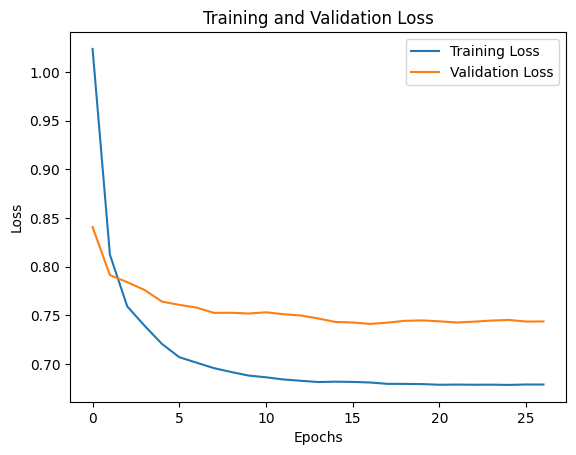

In [67]:
plt.plot(training.history['loss'])
plt.plot(training.history['val_loss']);
# add axis labels and legend!!
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Training Loss', 'Validation Loss'])
plt.title('Training and Validation Loss')
plt.show()

Figure 2: The model loss as a function of epoch for both the training and the validation data. The training loss drops sharply at the begining but becomes stable after epoch 10. The validation model loss stays around .75.

plot (visualize) the prediction and the ground truth for the test data. What do you see? where is the model succesful where is it not?

In [70]:
prediction = model.predict(X_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


In [71]:
prediction.shape

(6, 2516)

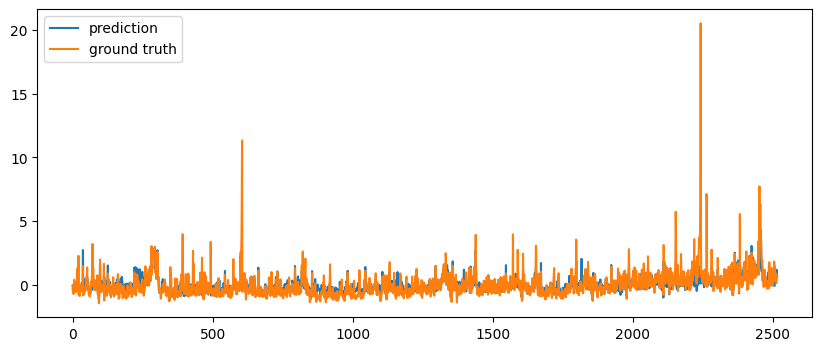

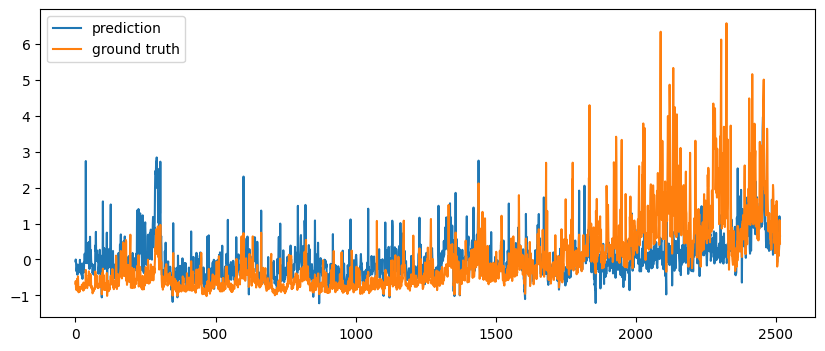

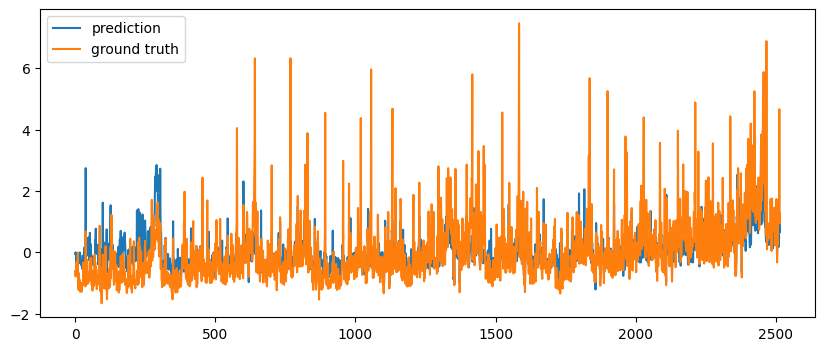

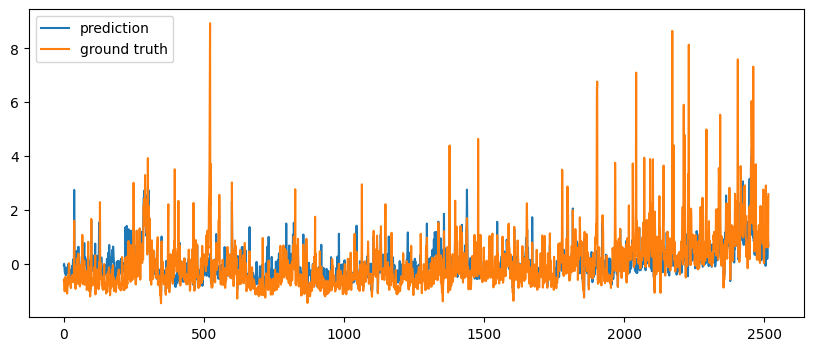

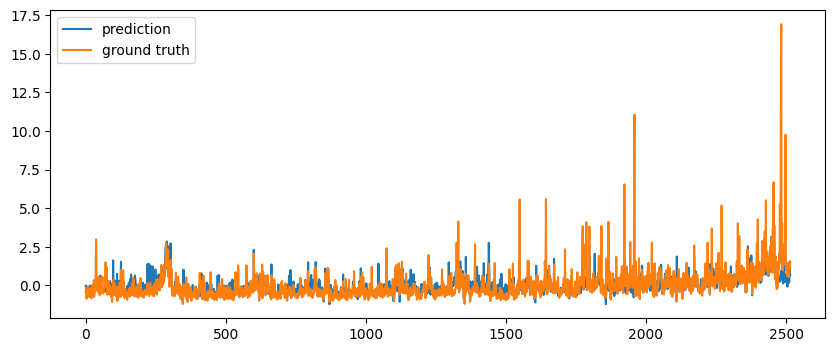

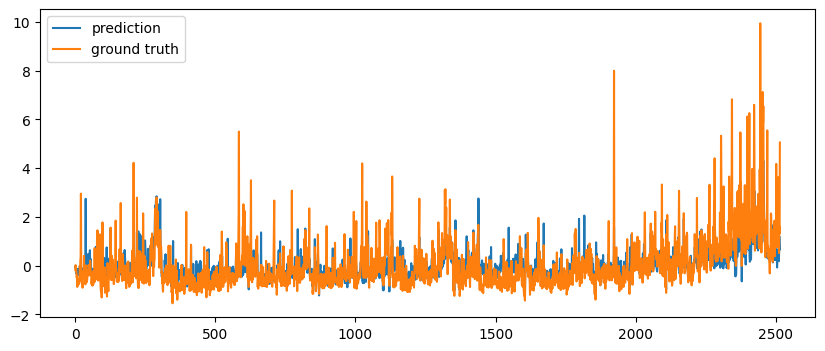

In [76]:
for i,_ in enumerate(X_test):
  pl.figure(figsize=(10, 4))
  pl.plot(prediction[i], label = 'prediction')
  pl.plot(X_test[i], label = 'ground truth', linestyle = '-')
  pl.legend()
  pl.show()

Figure 3: This figure shows both the prediction and the ground truth for each of the time series in the testing set. In each plot, the prediction is shown in blue while the ground truth is shown in orange. The prediction is good at mimicking the main trend and overall shapes of the data.

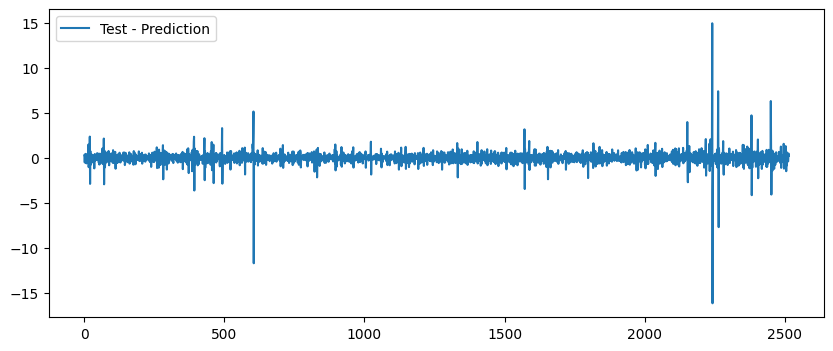

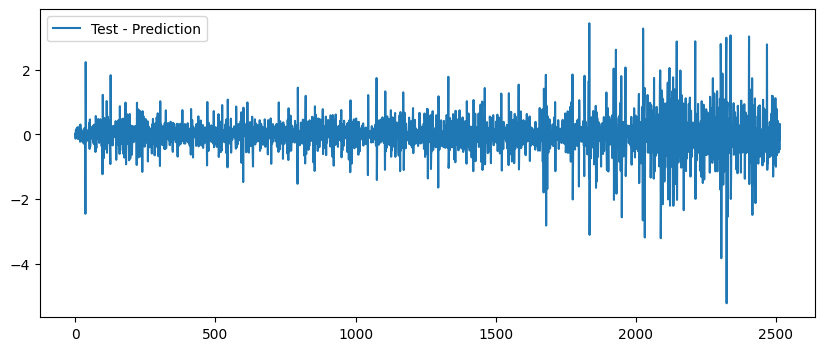

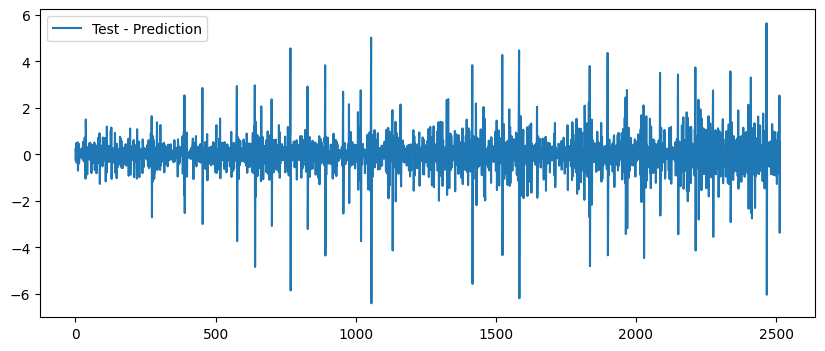

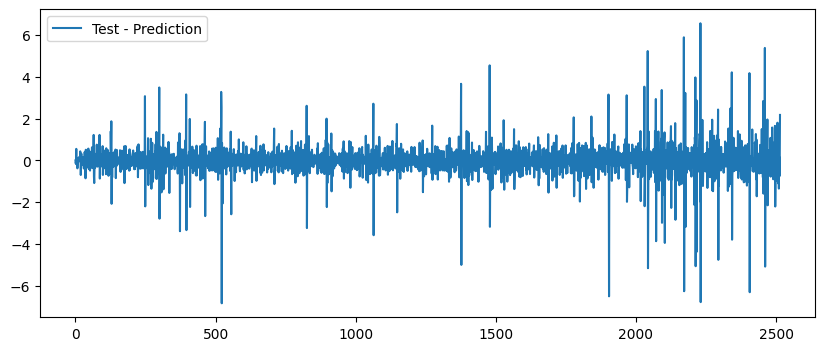

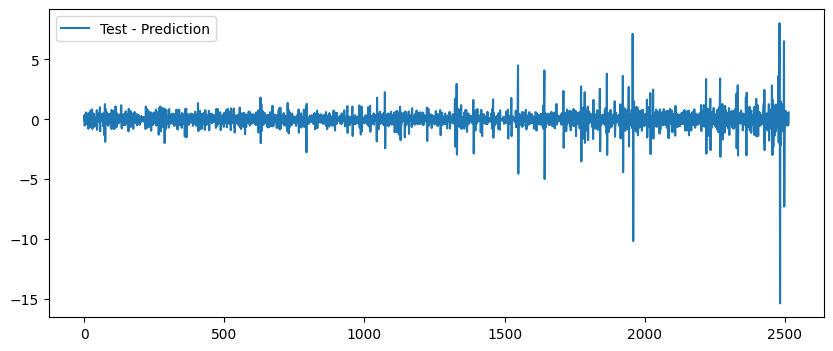

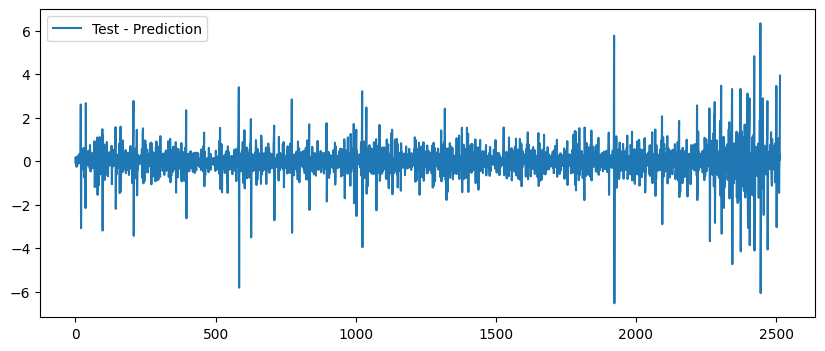

In [78]:
for i,_ in enumerate(X_test):
  pl.figure(figsize=(10, 4))
  pl.plot(np.diff(X_test[i]-prediction[i]), label = 'Test - Prediction')
  #pl.plot(X_test[i], label = 'ground truth', linestyle = '-')
  pl.legend()
  pl.show()

Figure 4: The plots show the difference between the predicted and actual stock prices (test minus prediction). Fluctuations are present, with the prediction sometimes higher and sometimes lower than the actual value. Some differences remain relatively constant over time, while others increase. Notably, the model struggles to capture a sharp peak in one stock price, indicating a poor fit for that specific behavior. The varying differences across stocks suggest the model may have difficulty fitting all datasets simultaneously, potentially due to overfitting the training data or needing more specialized approaches for different stocks